In [1]:
import xarray as xr
import os
import glob
import numpy as np
import warnings
import matplotlib.pyplot as plt
import sys
import cmocean

warnings.filterwarnings("ignore")
sys.path.append('../src')
sys.path.append('../src-double-gyre')
from plot_helpers import create_animation_ffmpeg, default_rcParams

%load_ext autoreload
%autoreload 3

# Figure explaining calibration process

In [20]:
def plot_ssh(data, vmax=2, cmap=cmocean.cm.balance, add_colorbar=False, axes=True, show_rmse=False, figsize=(4,4), **kw):
    levels_field = np.arange(-vmax,vmax+0.5,0.5)
    
    plt.figure(figsize=figsize)

    levels = np.arange(-vmax,vmax+0.5,0.5)
    data.plot.contourf(levels=levels, cmap=cmap, linewidths=1, extend='both', add_colorbar=add_colorbar, **kw)
    plt.title('')

    if axes:
        plt.xticks(np.arange(0,25,5), [f"{i}"+"$^{\circ}\mathrm{E}$" for i in np.arange(0,25,5)])
        plt.yticks(np.arange(30,55,5), [f"{i}"+"$^{\circ}\mathrm{N}$" for i in np.arange(30,55,5)])
        plt.xlabel('')
        plt.ylabel('')
    else:
        plt.xticks([])
        plt.yticks([])
        plt.xlabel('')
        plt.ylabel('')
    
    if show_rmse:
        rmse = float(np.sqrt(((data - observation_netcdf.e_mean.isel(zi=0))**2).mean()))
        plt.text(1,31,f'RMSE$={rmse:.2f}$m', fontsize=20)

    plt.gca().set_aspect(1)

In [21]:
metrics = xr.open_mfdataset('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_mean_only_scaling/metrics*')

In [22]:
observation_netcdf = xr.open_dataset('../scripts/R32/R2_FGR3_series_loss.nc')

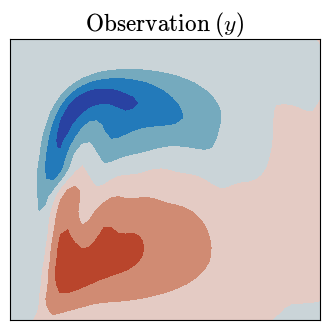

In [23]:
plot_ssh(observation_netcdf.e_mean.isel(zi=0),axes=False, add_colorbar=False)
plt.title('Observation ($y$)')
plt.savefig('paper_figures/fDNS-no-colorbar.pdf')

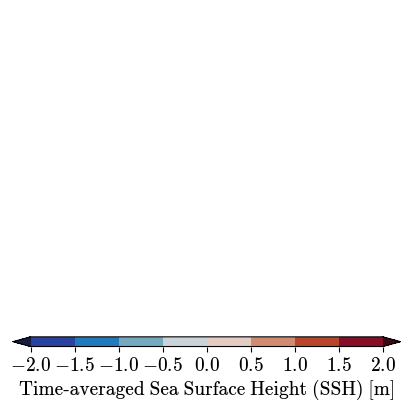

In [41]:
plot_ssh(observation_netcdf.e_mean.isel(zi=0)*np.nan, axes=False, add_colorbar=True, figsize=(5,5),
cbar_kwargs={'label': 'Time-averaged Sea Surface Height (SSH) [m]', 'shrink':1.0, 'aspect':40, 'orientation':'horizontal'})
plt.title('')
plt.gca().set_frame_on(False)
plt.savefig('paper_figures/fDNS.pdf')

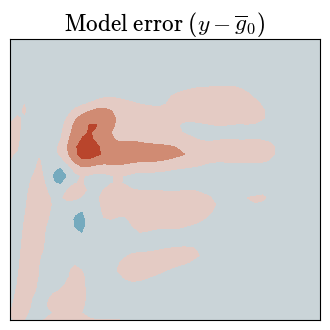

In [286]:
plot_ssh(observation_netcdf.e_mean.isel(zi=0) - metrics.isel(iter=0,zi=0).e_mean.mean('ens'),axes=False)
plt.title('Model error ($y - \overline{g}_0$)')
plt.savefig('paper_figures/model_error.pdf')

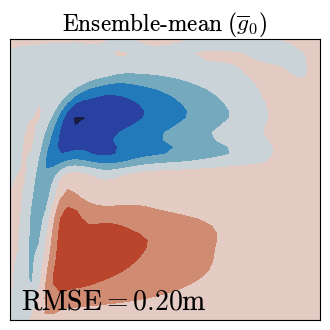

In [321]:
plot_ssh(metrics.isel(iter=0,zi=0).e_mean.mean('ens'),axes=False, show_rmse=True)
plt.title('Ensemble-mean ($\overline{g}_0$)')
plt.savefig('paper_figures/ensemble_mean.pdf')

In [260]:
model_error = observation_netcdf.e_mean.isel(zi=0) - metrics.isel(iter=0,zi=0).e_mean.mean('ens')
model_response = metrics.isel(iter=0,zi=0).e_mean - metrics.isel(iter=0,zi=0).e_mean.mean('ens')

In [261]:
(model_error * model_response).sum(['xh', 'yh']).values

array([  1.7863002 ,  28.922705  , -22.267393  ,  14.974466  ,
        17.397379  ,  -4.2011294 ,   6.633449  ,   9.103613  ,
        30.55229   ,  -0.36905253, -20.421946  ,  -8.1574545 ,
         0.        ,  18.056622  , -24.502853  ,   8.124358  ,
       -34.476604  ,  -7.9678516 ,   5.322609  , -17.313917  ,
       -21.797806  ,  21.925697  ,   0.        , -27.763968  ,
       -45.999577  ,   0.        ,  -3.5704486 ,  31.807316  ,
         0.        ,  -9.5846    ,   0.        ,  30.808937  ,
       -19.157406  , -33.978188  ,   0.        ,  45.61058   ,
       -20.433252  ,  26.783945  , -34.0828    ,  11.014891  ,
        16.861666  ,   0.        ,   0.        , -45.68458   ,
       -38.339954  ,  -7.161306  ,  -9.786346  ,   0.        ,
        17.495668  ,  21.483652  ,   4.4626684 ,  17.01449   ,
        -5.060383  ,   0.        ,   0.        ,  -3.4482841 ,
        40.08217   ,   0.        , -48.258392  ,  47.167915  ,
       -26.134384  ,  29.155212  ,  -4.892329  ,  31.15

In [292]:
xr.corr(model_error, model_response, ['xh', 'yh'])[-3].values


array(-0.581729, dtype=float32)

In [293]:
xr.corr(model_error, model_response, ['xh', 'yh'])[-41].values


array(0.44272238, dtype=float32)

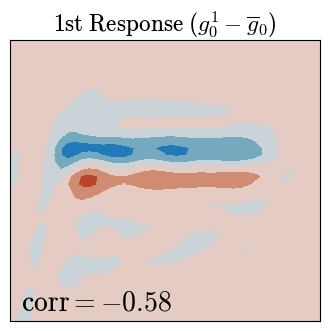

In [322]:
plot_ssh(metrics.isel(iter=0,zi=0,ens=-3).e_mean - metrics.isel(iter=0,zi=0).e_mean.mean('ens'),axes=False)
plt.title('1st Response ($g_0^1 - \overline{g}_0$)')
plt.text(1,31,'corr$=-0.58$', fontsize=20)
plt.savefig('paper_figures/model_response_1.pdf')

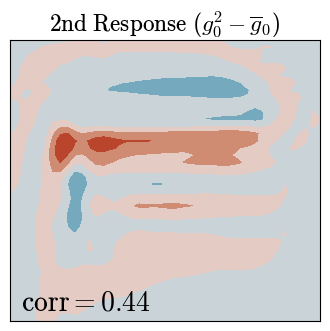

In [323]:
plot_ssh(metrics.isel(iter=0,zi=0,ens=-41).e_mean - metrics.isel(iter=0,zi=0).e_mean.mean('ens'),axes=False)
plt.title('2nd Response ($g_0^2 - \overline{g}_0$)')
plt.text(1,31,'corr$=0.44$', fontsize=20)
plt.savefig('paper_figures/model_response_2.pdf')

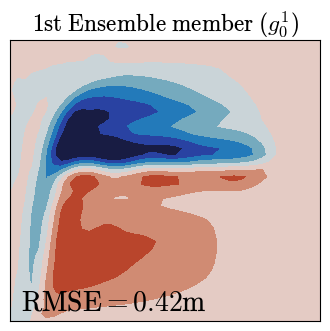

In [324]:
plot_ssh(metrics.isel(iter=0,zi=0,ens=-3).e_mean,axes=False, show_rmse=True)
plt.title('1st Ensemble member ($g_0^1$)')
plt.savefig('paper_figures/model_1.pdf')

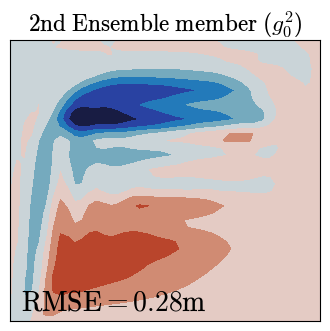

In [325]:
plot_ssh(metrics.isel(iter=0,zi=0,ens=-41).e_mean,axes=False, show_rmse=True)
plt.title('2nd Ensemble member ($g_0^2$)')
plt.savefig('paper_figures/model_2.pdf')

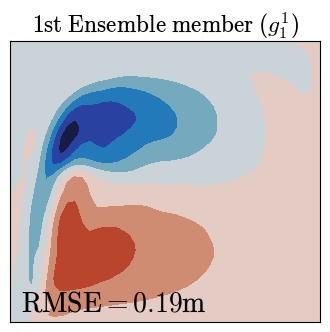

In [326]:
plot_ssh(metrics.isel(iter=1,zi=0,ens=-3).e_mean,axes=False, show_rmse=True)
plt.title('1st Ensemble member ($g_1^1$)')
plt.savefig('paper_figures/iter_1_model_1.pdf')

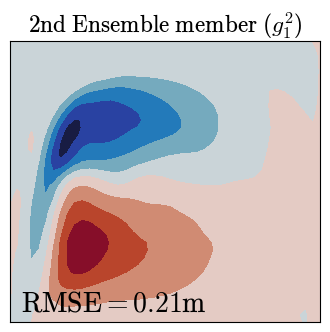

In [327]:
plot_ssh(metrics.isel(iter=1,zi=0,ens=-41).e_mean,axes=False, show_rmse=True)
plt.title('2nd Ensemble member ($g_1^2$)')
plt.savefig('paper_figures/iter_1_model_2.pdf')

# Resolving eddy energy

In [2]:
from helpers.collection_of_experiments import CollectionOfExperiments

In [3]:
ds = CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/filtered', additional_subfolder='output')

In [4]:
ds += CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/bare', additional_subfolder='output')

In [5]:
%time ds +=  CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/generalization', additional_subfolder='output')

CPU times: user 20.9 ms, sys: 144 ms, total: 165 ms
Wall time: 2.63 s


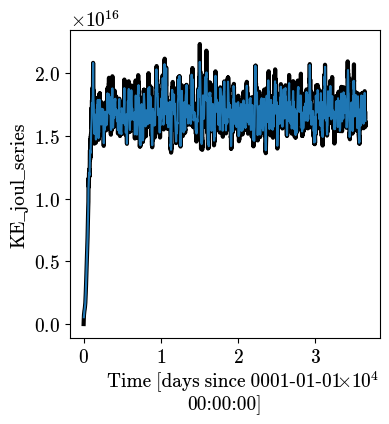

In [21]:
ds['R32'].series.KE.sum('Layer').plot(lw=3, color='k')
ds['R32'].KE_joul_series.sum('zl').plot()

In [14]:
ds['R32'].EKE_joul.sum().values

array(1.08218888e+16)

In [15]:
ds['R32_R2_FGR3'].EKE_joul.sum().values / ds['R32'].EKE_joul.sum().values * 100

23.863317394818935

In [16]:
ds['R2'].EKE_joul.sum().values / ds['R32'].EKE_joul.sum().values * 100


0.34102843507692165

# Same but in EKE spectrum

In [16]:
dd = {}
for exp in ['R2','R32_R2_FGR3', 'R32']:
    sp = ds[exp].EKE_spectrum.isel(zl=0)
    dd[exp] = float(np.sum(sp * np.diff(sp.freq_r)[0]).compute())

In [27]:
round(dd['R32_R2_FGR3'] / dd['R32'],2) * 100

23.0

In [28]:
round(dd['R2'] / dd['R32'],2) * 100

1.0

# Figure showing an amount of resolved EKE

(20, 22) (20, 22)


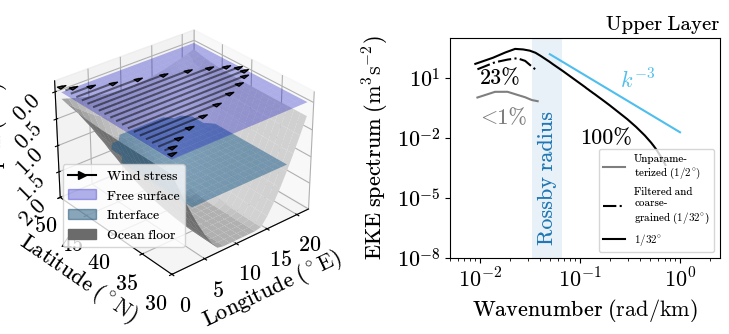

In [62]:
import cmocean
default_rcParams({'font.size': 16,'axes.formatter.limits': (-2,4), 'figure.subplot.wspace': 0.5, 'figure.subplot.hspace': 0.4})
fig = plt.figure(figsize=(9,4))
lightblue = [0.3010, 0.7450, 0.9330]
exps =['R2', 'R32_R2_FGR3', 'R32']
labels=['Unparame-\nterized ($1/2^{\circ})$', 'Filtered and \ncoarse-\ngrained ($1/32^{\circ}$)', '$1/32^{\circ}$']
colors = ['tab:gray', 'k', 'k']
lss = ['-', '-.', '-']
def plot_spectrum(zl=0):
    for exp,label,color,ls in zip(exps,labels,colors,lss):
        ds[exp].EKE_spectrum.isel(zl=zl).plot(label=label,color=color,ls=ls)
    plt.xlabel(r'Wavenumber ($\mathrm{rad}/\mathrm{km}$)')
    plt.ylabel('EKE spectrum ($\mathrm{m}^3\mathrm{s}^{-2}$)')
    k = [5e-5, 1e-3]
    E = [1.5e+2, 0]
    plt.text(2.5e-4,0.3e+1,'$k^{-3}$',color=lightblue)
    E[1] = E[0] * (k[1]/k[0])**(-3)
    plt.loglog(k,E,ls='-', color=lightblue)
    plt.title('')
    plt.ylim([1e-8,1e+3])
    plt.xticks([1e-5,1e-4,1e-3],['$10^{-2}$', '$10^{-1}$', '$10^{0}$'])
    plt.xlim([5e-6, 2.5e-3])
    plt.text(1e-5, 5e-2, '<1%', color='tab:gray')
    plt.text(1e-5, 5e0, '23%', color='k')
    plt.text(1e-4, 5e-3, '100%', color='k')
    
def plot_vorticity(exp):
    field = ds[exp].RV_f.isel(zl=0,Time=-1)
    if exp=='R64':
        field = field.coarsen(xq=2,yq=2,boundary='trim').mean().compute()
    im = field.plot.imshow(vmin=-0.2, vmax=0.2, cmap=cmocean.cm.balance, add_colorbar=False, interpolation='none')#, rasterized=True) #interpolation='none',
    plt.xticks([0,5,10,15,20])
    plt.yticks([30,35,40,45,50])
    plt.xlim([0,22])
    plt.ylim([30,50])
    plt.xlabel('Longitude ($^\circ\mathrm{E}$)')
    plt.ylabel('Latitude ($^\circ\mathrm{N}$)')
    plt.title('')
    plt.gca().set_aspect(1)
    return im

ax = fig.add_axes([0.1, 0.12, 0.4, 0.7], projection='3d')
ds.plot_domain(ax)
plt.xlabel('Longitude ($^\circ\mathrm{E}$)')
plt.ylabel('Latitude ($^\circ\mathrm{N}$)')

ax = fig.add_axes([0.6, 0.2, 0.3, 0.55]); plt.sca(ax)
plot_spectrum(zl=0)
# Baroclinic deformation radius
Rd1 = 30000
Rd2 = 15000
#plt.title('Upper Layer')
plt.axvspan(1/Rd1, 1/Rd2, color='tab:blue', alpha=0.1, lw=0)
plt.text(3.8e-5,1e-4,'Rossby radius', fontsize=16, color='tab:blue', rotation='vertical', verticalalignment='center')
plt.title('Upper Layer', loc='right', fontsize=15)
#plt.title('')
#plt.legend(ncol=5, bbox_to_anchor=(2.6,-0.25), title='Biharmonic Smagorinsky models with $C_S=0.06$')
plt.legend(ncol=1, fontsize=8, loc='lower right')

# fig.text(0.15,0.08,'(a)', fontsize=20);
# fig.text(0.45,0.08,'(b)', fontsize=20);
# fig.text(0.70,0.08,'(c)', fontsize=20);

plt.savefig('paper_figures/DoubleGyre.pdf', pad_inches=0.3, dpi=200)

# Figure showing results of calibration process

In [43]:
%time ds +=  CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_gprime', additional_subfolder='output', prefix='R2_FGR3_gprime')

NameError: name 'ds' is not defined

In [17]:
%time ds +=  CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_gprime_2', additional_subfolder='output', prefix='R2_FGR3_gprime_2')

CPU times: user 293 ms, sys: 972 ms, total: 1.26 s
Wall time: 18.8 s


In [24]:
%time ds +=  CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_gprime_2_boundary', additional_subfolder='output', prefix='R2_FGR3_gprime_2_boundary')

CPU times: user 57.4 ms, sys: 125 ms, total: 182 ms
Wall time: 3.68 s


In [38]:
from helpers.computational_tools import Lk_error
def plot_ssh(self, exps, labels=None, target=None, ncols=3, zi=0, vmax=2.0, cmap='RdBu_r', clabel=True, show_rmse=True):
    if labels is None:
        labels=exps
    nfig = len(exps)
    ncol = min(ncols,nfig)
    nrows = nfig / ncols
    if nrows > 1:
        nrows = int(np.ceil(nrows))
    else:
        nrows = 1

    if zi == 0:
        levels_field = np.arange(-vmax,vmax+0.5,0.5)
        levels_bias = np.arange(-2,2.2,0.2)
    else:
        levels_field = np.arange(-1400,-550,50)
        levels_bias = np.arange(-100,110,10)

    
    plt.figure(figsize=(15,6))
    plt.subplots_adjust(hspace=0.05, wspace=0.05)

    for ifig, exp in enumerate(exps):
        plt.subplot(nrows,ncol,ifig+1)
        ssh = self[exp].e_mean.isel(zi=zi)
        levels = levels_field
        label = 'SSH [m]'
        lines = True
        im = ssh.plot.contourf(levels=levels, cmap=cmap, linewidths=1, extend='both', add_colorbar=False)
        if lines:
            Cplot = ssh.plot.contour(levels=levels, colors='k', linewidths=1)
            if clabel:
                plt.gca().clabel(Cplot, Cplot.levels)
        plt.xticks(())
        plt.yticks((30, 35, 40, 45, 50))
        plt.xlabel('')
        plt.ylabel('Latitude')
        plt.title(labels[ifig])

        if exp != exps[-1]:
            RMSE = Lk_error(self[exp].e_mean.isel(zi=zi),self[exps[-1]].e_mean.isel(zi=zi))[0]
            corr = float(xr.corr(self[exp].e_mean.isel(zi=zi),self[exps[-1]].e_mean.isel(zi=zi)))
            #print(RMSE)
            if show_rmse:
                plt.text(11,33,'RMSE='+str(round(RMSE,3))+'m', fontsize=14)
                plt.text(11,31,'corr='+str(round(corr,3)), fontsize=14)
        plt.gca().set_aspect(1)

    plt.colorbar(im, ax = plt.gcf().axes, label='Time-averaged \nSea Surface Height (SSH) [m]', shrink=0.6)

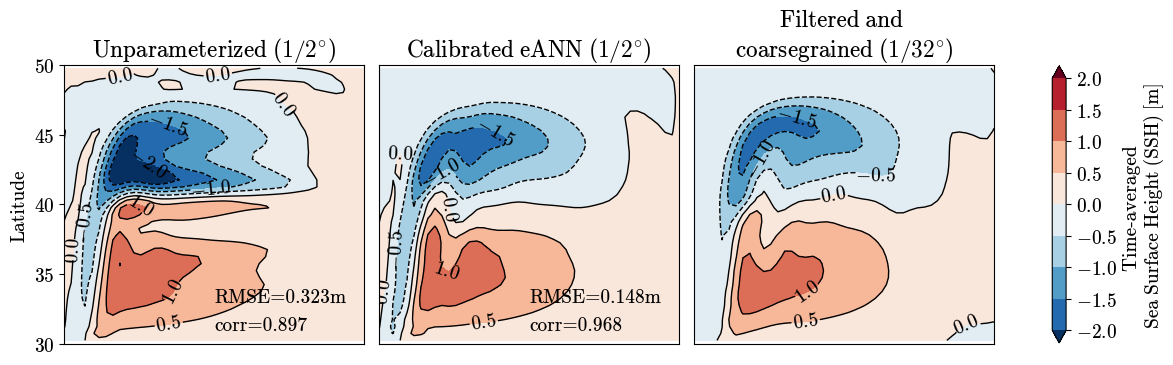

In [39]:
default_rcParams()
plot_ssh(ds, ['R2-100-years', 'R2_FGR3_gprime_2-iteration-05-ens-member-100-100years', 'R32_R2_FGR3'],
        ['Unparameterized ($1/2^{\circ}$)', 'Calibrated eANN ($1/2^{\circ}$)', 'Filtered and \ncoarsegrained ($1/32^{\circ}$)'])
for j in range(2,4):
    plt.subplot(1,3,j)
    plt.ylabel('')
    plt.yticks([])
plt.savefig('paper_figures/figure2-mean.pdf')

In [40]:
def plot_ssh_std(self, exps, labels=None, target=None, ncols=3, zi=0, vmax=3.0, cmap=cmocean.cm.amp, show_rmse=True):
    if labels is None:
        labels=exps
    nfig = len(exps)
    ncol = min(ncols,nfig)
    nrows = nfig / ncols
    if nrows > 1:
        nrows = int(np.ceil(nrows))
    else:
        nrows = 1

    if zi == 0:
        levels = np.arange(0,0.65,0.05)
    else:
        levels = np.arange(0,65,5)

    
    plt.figure(figsize=(15,6))
    plt.subplots_adjust(hspace=0.05, wspace=0.05)

    for ifig, exp in enumerate(exps):
        plt.subplot(nrows,ncol,ifig+1)
        ssh_std = self[exp].e_std.isel(zi=zi)
        im = ssh_std.plot.contourf(levels=levels, cmap=cmap, extend='both', add_colorbar=False)
        plt.xticks((0,5,10,15,20))
        plt.yticks((30, 35, 40, 45, 50))
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.title(labels[ifig])

        if exp != exps[-1]:
            RMSE = Lk_error(self[exp].e_std.isel(zi=zi),self[exps[-1]].e_std.isel(zi=zi))[0]
            corr = float(xr.corr(self[exp].e_std.isel(zi=zi),self[exps[-1]].e_std.isel(zi=zi)))
            #print(RMSE)
            if show_rmse:
                plt.text(11,33,'RMSE='+str(round(RMSE,3))+'m', fontsize=14, color='k')
                plt.text(11,31,'corr='+str(round(corr,3)), fontsize=14, color='k')
        plt.gca().set_aspect(1)

    plt.colorbar(im, ax = plt.gcf().axes, label='Temporal STD of SSH [m]', shrink=0.6)

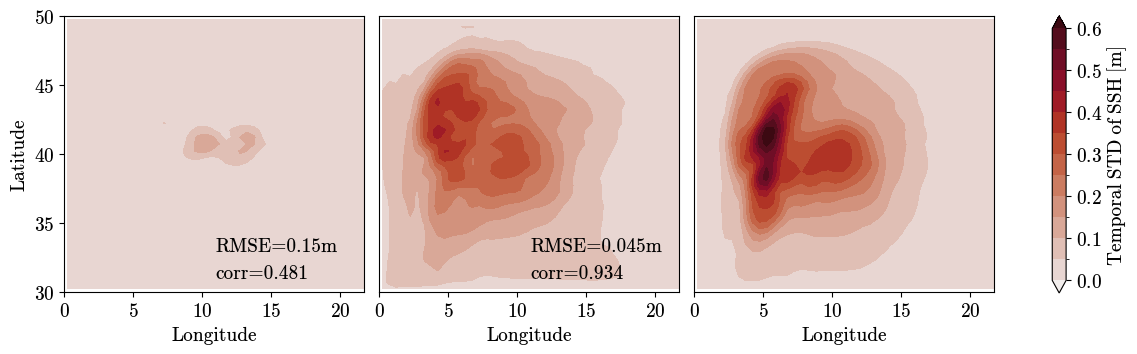

In [41]:
default_rcParams()
plot_ssh_std(ds, ['R2-100-years', 'R2_FGR3_gprime_2-iteration-05-ens-member-100-100years', 'R32_R2_FGR3'],
        ['', '', ''])
for j in range(2,4):
    plt.subplot(1,3,j)
    plt.ylabel('')
    plt.yticks([])
plt.savefig('paper_figures/figure2-std.pdf')

(0.0, 5000000000000000.0)

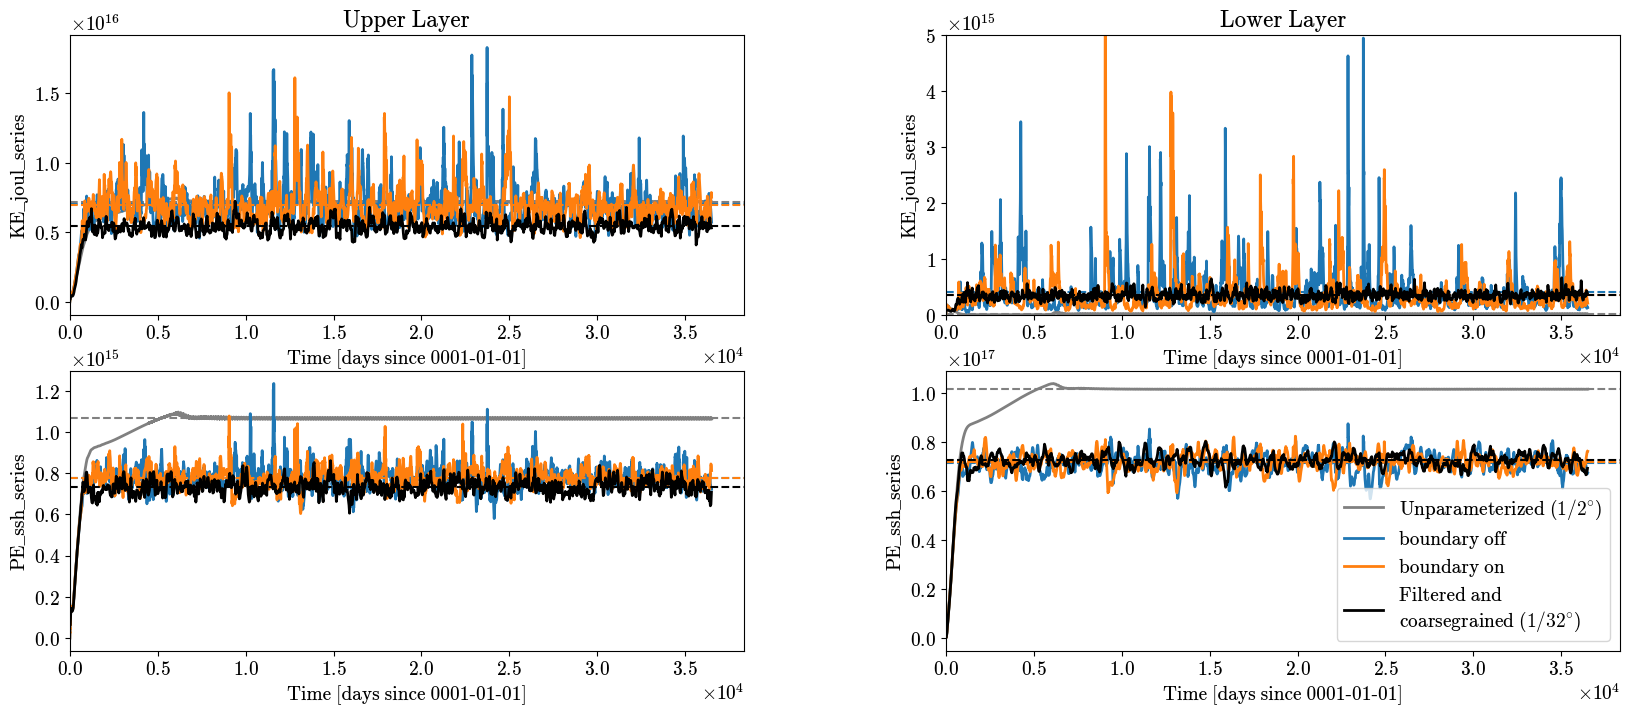

In [37]:
ds.plot_series(['R2-100-years', 'R2_FGR3_gprime_2_boundary-iteration-05-ens-member-100-100years', 'R2_FGR3_gprime_2-iteration-05-ens-member-100-100years', 'R32_R2_FGR3'],
['Unparameterized ($1/2^{\circ}$)', 'boundary off', 'boundary on', 'Filtered and \ncoarsegrained ($1/32^{\circ}$)'])
plt.subplot(2,2,2)
plt.ylim([0,5e+15])
#plt.savefig('paper_figures/figure2-series.pdf')

# Convergence of metrics

In [46]:
metrics = xr.open_mfdataset('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_gprime_2/recompute_metrics/metrics*')

In [47]:
# Here we rescale RMSE so we account for upper and lower interfaces together
npoints = 40 * 44 * 2
e_mean_rmse = np.sqrt(metrics.e_mean_WSE.sum('zi', skipna=False) / npoints)
e_std_rmse = np.sqrt(metrics.e_std_WSE.sum('zi', skipna=False) / npoints)
cov_rmse = metrics.covariance_matrix_4_RMSE
e_3rd_rmse = np.sqrt(metrics.e_3rd_WSE.sum('zi', skipna=False) / npoints)
e_4th_rmse = np.sqrt(metrics.e_4th_WSE.sum('zi', skipna=False) / npoints)

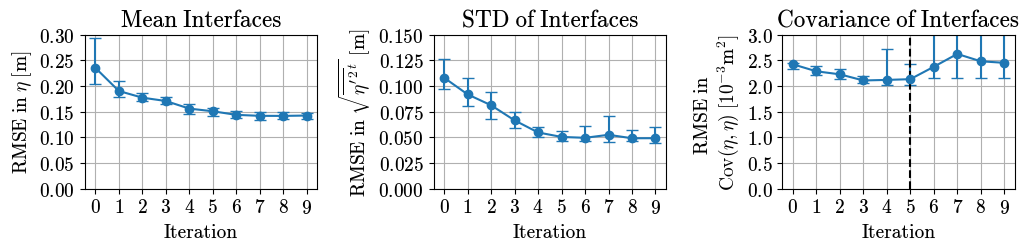

In [48]:
default_rcParams()
plt.figure(figsize=(12,2))
plt.subplots_adjust(hspace=0.05, wspace=0.5)
plt.subplot(1,3,1)
data = e_mean_rmse.copy()
mean = data.median('ens')
q25  = data.quantile(0.25, 'ens')
q75  = data.quantile(0.75, 'ens')
lower = mean - q25
upper = q75 - mean
yerr = np.vstack([lower.values, upper.values])
x = mean.iter
plt.errorbar(x, mean, yerr=yerr, fmt='o', capsize=4, color='tab:blue', ls='-')
plt.ylim([0, 0.3])
plt.xticks(np.arange(10))
plt.grid()
plt.yticks(np.arange(0,0.35,0.05));
plt.title('Mean Interfaces')
plt.ylabel('RMSE in $\eta$ [m]')
plt.xlabel('Iteration')

plt.subplot(1,3,2)
data = e_std_rmse.copy()
mean = data.median('ens')
q25  = data.quantile(0.25, 'ens')
q75  = data.quantile(0.75, 'ens')
lower = mean - q25
upper = q75 - mean
yerr = np.vstack([lower.values, upper.values])
x = mean.iter
plt.errorbar(x, mean, yerr=yerr, fmt='o', capsize=4, color='tab:blue', ls='-')
plt.ylim([0, 0.15])
plt.xticks(np.arange(10))
plt.grid()
plt.yticks(np.arange(0,0.175,0.025));
plt.title('STD of Interfaces')
plt.ylabel('RMSE in $\\sqrt{\\overline{\\eta\'^2}^t}$ [m]')
plt.xlabel('Iteration')

plt.subplot(1,3,3)
data = 1.e+3 * cov_rmse.copy()
mean = data.median('ens')
q25  = data.quantile(0.25, 'ens')
q75  = data.quantile(0.75, 'ens')
lower = mean - q25
upper = q75 - mean
yerr = np.vstack([lower.values, upper.values])
x = mean.iter
plt.errorbar(x, mean, yerr=yerr, fmt='o', capsize=4, color='tab:blue', ls='-')
plt.ylim([0,3])
plt.yticks(np.arange(0,3.5,0.5))
plt.xticks(np.arange(10))
plt.grid()
plt.title('Covariance of Interfaces')
plt.ylabel('RMSE in \n$\\mathrm{Cov}(\eta,\eta)$ [$10^{-3}$m$^2$]')
plt.xlabel('Iteration')
plt.axvline(x=5,ls='--', color='k')
plt.savefig('paper_figures/figure2-metric.pdf')

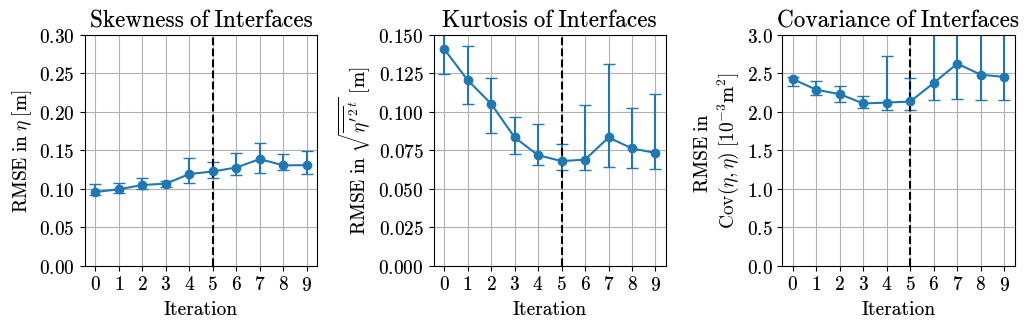

In [49]:
default_rcParams()
plt.figure(figsize=(12,3))
plt.subplots_adjust(hspace=0.05, wspace=0.5)
plt.subplot(1,3,1)
data = e_3rd_rmse.copy()
mean = data.median('ens')
q25  = data.quantile(0.25, 'ens')
q75  = data.quantile(0.75, 'ens')
lower = mean - q25
upper = q75 - mean
yerr = np.vstack([lower.values, upper.values])
x = mean.iter
plt.errorbar(x, mean, yerr=yerr, fmt='o', capsize=4, color='tab:blue', ls='-')
plt.ylim([0, 0.3])
plt.xticks(np.arange(10))
plt.grid()
plt.yticks(np.arange(0,0.35,0.05));
plt.title('Skewness of Interfaces')
plt.ylabel('RMSE in $\eta$ [m]')
plt.xlabel('Iteration')
plt.axvline(x=5,ls='--', color='k')

plt.subplot(1,3,2)
data = e_4th_rmse.copy()
mean = data.median('ens')
q25  = data.quantile(0.25, 'ens')
q75  = data.quantile(0.75, 'ens')
lower = mean - q25
upper = q75 - mean
yerr = np.vstack([lower.values, upper.values])
x = mean.iter
plt.errorbar(x, mean, yerr=yerr, fmt='o', capsize=4, color='tab:blue', ls='-')
plt.ylim([0, 0.15])
plt.xticks(np.arange(10))
plt.grid()
plt.yticks(np.arange(0,0.175,0.025));
plt.title('Kurtosis of Interfaces')
plt.ylabel('RMSE in $\\sqrt{\\overline{\\eta\'^2}^t}$ [m]')
plt.xlabel('Iteration')
plt.axvline(x=5,ls='--', color='k')

plt.subplot(1,3,3)
data = 1.e+3 * cov_rmse.copy()
mean = data.median('ens')
q25  = data.quantile(0.25, 'ens')
q75  = data.quantile(0.75, 'ens')
lower = mean - q25
upper = q75 - mean
yerr = np.vstack([lower.values, upper.values])
x = mean.iter
plt.errorbar(x, mean, yerr=yerr, fmt='o', capsize=4, color='tab:blue', ls='-')
plt.ylim([0,3])
plt.yticks(np.arange(0,3.5,0.5))
plt.xticks(np.arange(10))
plt.grid()
plt.title('Covariance of Interfaces')
plt.ylabel('RMSE in \n$\\mathrm{Cov}(\eta,\eta)$ [$10^{-3}$m$^2$]')
plt.xlabel('Iteration')
plt.axvline(x=5,ls='--', color='k')

#plt.savefig('paper_figures/figure2-metric.pdf')

# Model selection for NW2

In [2]:
metrics = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/calibration/1800days/gprime_n/metrics*')

In [3]:
# Here we rescale RMSE so we account for upper and lower interfaces together
npoints = 120 * 280 * 15
e_mean_rmse = np.sqrt(metrics.e_mean_WSE.sum('zi', skipna=False) / npoints)
e_std_rmse = np.sqrt(metrics.e_std_WSE.sum('zi', skipna=False) / npoints)
#cov_rmse = metrics.cov_fro_distance_10
e_3rd_rmse = np.sqrt(metrics.e_3rd_WSE.sum('zi', skipna=False) / npoints)
e_4th_rmse = np.sqrt(metrics.e_4th_WSE.sum('zi', skipna=False) / npoints)

Text(0.5, 0, 'Iteration')

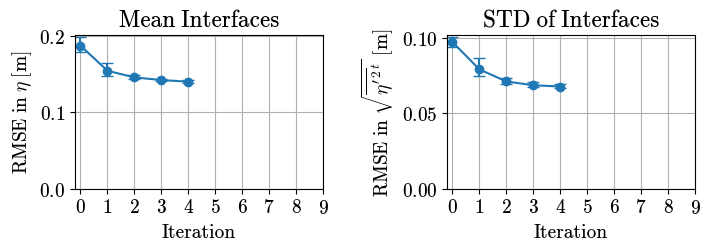

In [6]:
default_rcParams()
plt.figure(figsize=(8,2))
plt.subplots_adjust(hspace=0.05, wspace=0.5)
plt.subplot(1,2,1)
data = e_mean_rmse.copy()
mean = data.median('ens')
q25  = data.quantile(0.25, 'ens')
q75  = data.quantile(0.75, 'ens')
lower = mean - q25
upper = q75 - mean
yerr = np.vstack([lower.values, upper.values])
x = mean.iter
plt.errorbar(x, mean, yerr=yerr, fmt='o', capsize=4, color='tab:blue', ls='-')
plt.ylim([0,None])
plt.xticks(np.arange(10))
plt.grid()
plt.title('Mean Interfaces')
plt.ylabel('RMSE in $\eta$ [m]')
plt.xlabel('Iteration')

plt.subplot(1,2,2)
data = e_std_rmse.copy()
mean = data.median('ens')
q25  = data.quantile(0.25, 'ens')
q75  = data.quantile(0.75, 'ens')
lower = mean - q25
upper = q75 - mean
yerr = np.vstack([lower.values, upper.values])
x = mean.iter
plt.errorbar(x, mean, yerr=yerr, fmt='o', capsize=4, color='tab:blue', ls='-')
plt.xticks(np.arange(10))
plt.grid()
plt.ylim([0,None])
plt.title('STD of Interfaces')
plt.ylabel('RMSE in $\\sqrt{\\overline{\\eta\'^2}^t}$ [m]')
plt.xlabel('Iteration')

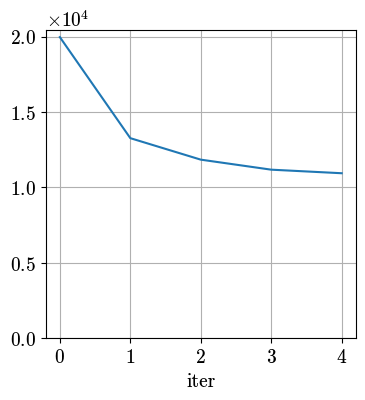

In [11]:
(metrics.e_mean_WSE_MAP + metrics.e_std_WSE_MAP).sum('zi').plot()
plt.ylim([0,None])
plt.grid()
#plt.yticks(np.arange(0,800,100));

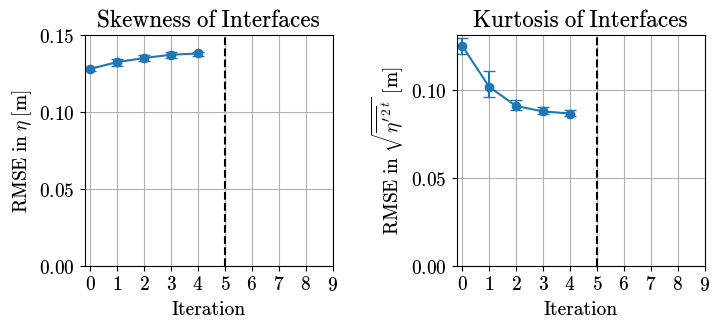

In [13]:
default_rcParams()
plt.figure(figsize=(8,3))
plt.subplots_adjust(hspace=0.05, wspace=0.5)
plt.subplot(1,2,1)
data = e_3rd_rmse.copy()
mean = data.median('ens')
q25  = data.quantile(0.25, 'ens')
q75  = data.quantile(0.75, 'ens')
lower = mean - q25
upper = q75 - mean
yerr = np.vstack([lower.values, upper.values])
x = mean.iter
plt.errorbar(x, mean, yerr=yerr, fmt='o', capsize=4, color='tab:blue', ls='-')
plt.ylim([0, 0.15])
plt.xticks(np.arange(10))
plt.grid()
#plt.yticks(np.arange(0,0.35,0.05));
plt.title('Skewness of Interfaces')
plt.ylabel('RMSE in $\eta$ [m]')
plt.xlabel('Iteration')
plt.axvline(x=5,ls='--', color='k')

plt.subplot(1,2,2)
data = e_4th_rmse.copy()
mean = data.median('ens')
q25  = data.quantile(0.25, 'ens')
q75  = data.quantile(0.75, 'ens')
lower = mean - q25
upper = q75 - mean
yerr = np.vstack([lower.values, upper.values])
x = mean.iter
plt.errorbar(x, mean, yerr=yerr, fmt='o', capsize=4, color='tab:blue', ls='-')
plt.ylim([0, None])
plt.xticks(np.arange(10))
plt.grid()
#plt.yticks(np.arange(0,0.175,0.025));
plt.title('Kurtosis of Interfaces')
plt.ylabel('RMSE in $\\sqrt{\\overline{\\eta\'^2}^t}$ [m]')
plt.xlabel('Iteration')
plt.axvline(x=5,ls='--', color='k')

In [14]:
observation = xr.open_dataset('/home/pp2681/calibration/scripts/R32_R2_FGR3_NW2/800days_v3.nc').astype('float64')
metrics = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/calibration/1800days/gprime_n/metrics*')
def plot_metrics(color='tab:blue'):
    try:
        metrics['e_mean_RMSE'] = metrics['RMSE_e_mean']
        metrics['e_std_RMSE'] = metrics['RMSE_e_std']
    except:
        pass

    j=0
    for layer in range(15):
        for metric, label in zip(
            [
                'KE_mean',
                'KE_std',
                'APE_mean',
                'APE_std',
                'e_mean_RMSE',
                'e_std_RMSE',
            ],
            [
                'KE mean [PJ]',
                'KE std [PJ]',
                'APE mean [PJ]',
                'APE std [PJ]',
                'Interface mean RMSE [m]',
                'Interface std RMSE [m]',
            ]):
            j = j + 1
            data = metrics[metric]
            if 'zi' in data.dims:
                layer_coord = 'zi'
            elif 'zl' in data.dims:
                layer_coord = 'zl'

            data = data[{layer_coord: layer}]

            try:
                truth = observation[metric][{layer_coord: layer}]
            except:
                truth = np.nan
            
            plt.subplot(15,6,j)

            mean = data.median('ens')
            q25  = data.quantile(0.25, 'ens')
            q75  = data.quantile(0.75, 'ens')
            lower = mean - q25
            upper = q75 - mean
            yerr = np.vstack([lower.values, upper.values])
            x = mean.iter
            plt.errorbar(x, mean, yerr=yerr, fmt='o', capsize=4, color=color, ls='-')
            plt.title(label)

            plt.axhline(y=truth, color='k', ls='--')

            plt.grid()
            plt.ylim([0,None])
            plt.xticks(np.arange(10))

    plt.tight_layout()
    plt.legend()

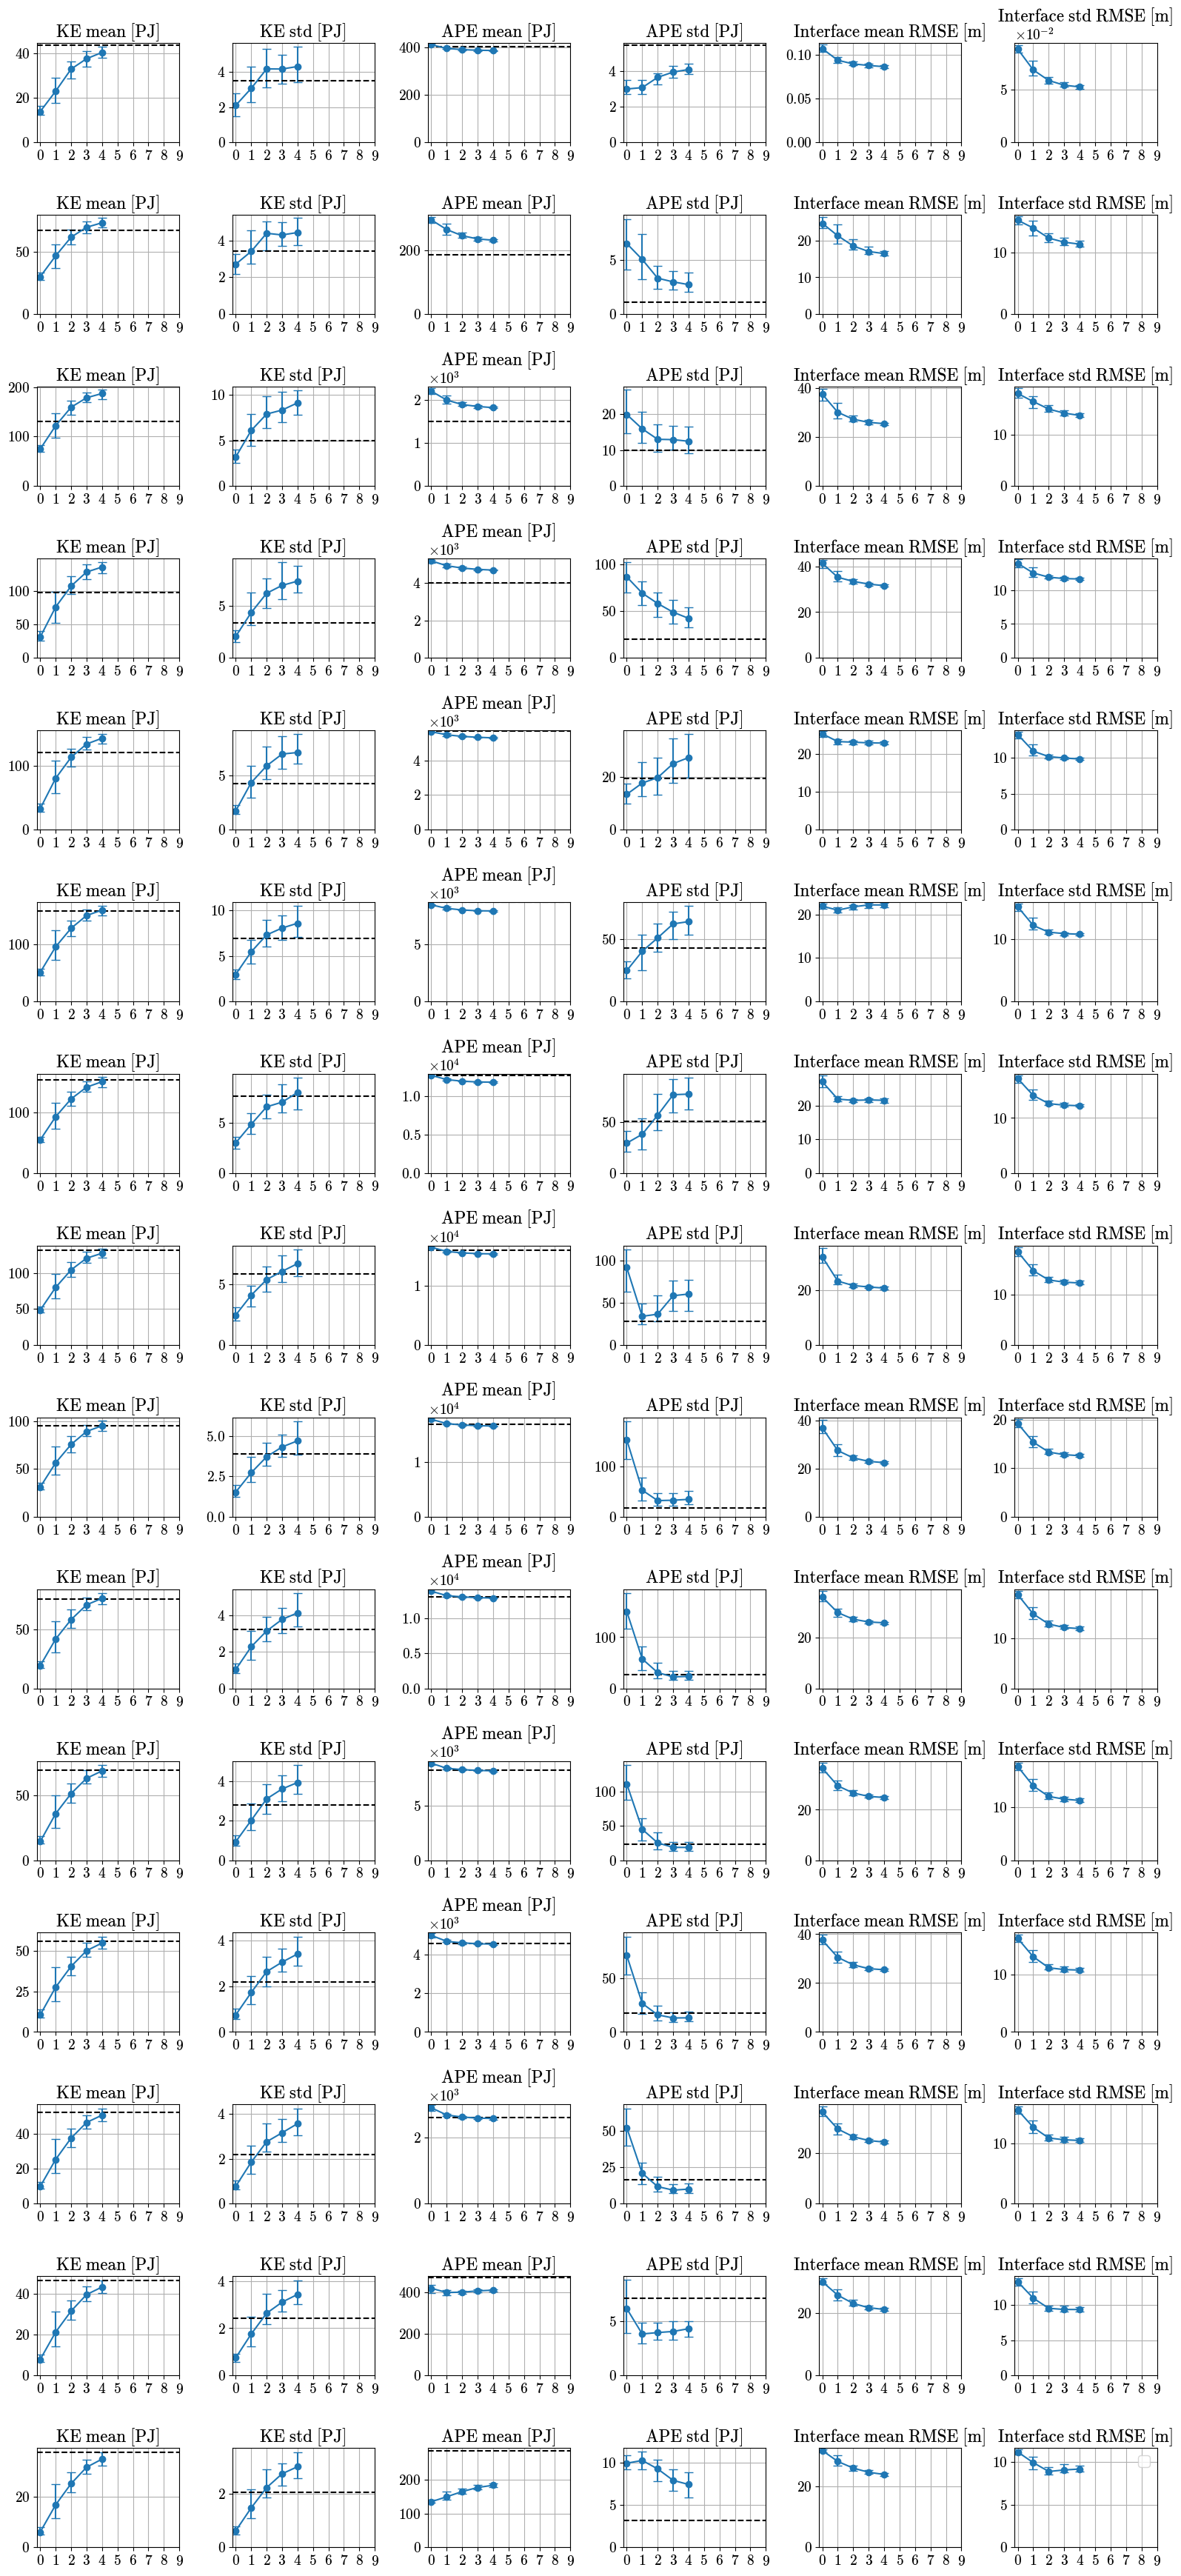

In [15]:
plt.figure(figsize=(16,35))
plot_metrics()
plt.savefig('paper_figures/NW2-all-metrics_gprime_n.pdf')

# Show mean and std for NW2

In [2]:
unparameterized = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long/bare-stable/output/snapshots_00029010.nc', decode_times=False).isel(time=slice(-160,None))
eANN_offline = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-ANN/eANN-noncalibrated/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_DG = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-gprime_2-DG-0.65/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_NW2 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-NW2-gprime_n-it3-ens-200-default/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
Yankovsky24 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/Yankovsky24-1.0/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
truth = xr.open_dataset('/home/pp2681/calibration/scripts/R32_R2_FGR3_NW2/800days_v3.nc')

In [3]:
mask_nan = eANN_offline.e.isel(time=-1)*0 + 1

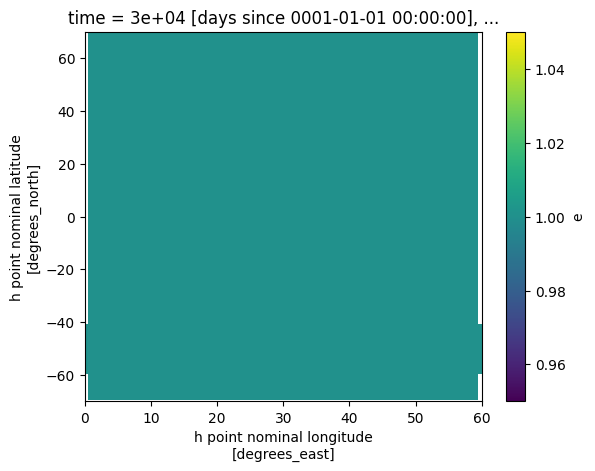

In [4]:
mask_nan[0].plot()

In [5]:
std_dict = {
    'unparameterized': unparameterized.e.std('time').compute(),
    'eANN_offline': eANN_offline.e.std('time').compute(),
    'eANN_DG': eANN_DG.e.std('time').compute(),
    'eANN_NW2': eANN_NW2.e.std('time').compute(),
    'Yankovsky24': Yankovsky24.e.std('time').compute(),
    'truth': (mask_nan*truth.e_std).compute()
}

In [6]:
mean_dict = {
    'unparameterized': unparameterized.e.mean('time').compute(),
    'eANN_offline': eANN_offline.e.mean('time').compute(),
    'eANN_DG': eANN_DG.e.mean('time').compute(),
    'eANN_NW2': eANN_NW2.e.mean('time').compute(),
    'Yankovsky24': Yankovsky24.e.mean('time').compute(),
    'truth': (mask_nan*truth.e_mean).compute()
}

In [7]:
interface_dict = {
    'unparameterized': unparameterized.e.mean('xh').mean('time').compute(),
    'eANN_offline': eANN_offline.e.mean('xh').mean('time').compute(),
    'eANN_DG': eANN_DG.e.mean('xh').mean('time').compute(),
    'eANN_NW2': eANN_NW2.e.mean('xh').mean('time').compute(),
    'Yankovsky24': Yankovsky24.e.mean('xh').mean('time').compute(),
    'truth': (mask_nan*truth.e_mean).mean('xh').compute()
}

In [8]:
from helpers.computational_tools import Lk_error
def plot_ssh(self, exps, labels=None, target=None, ncols=6, zi=0, vmax=4.0, cmap='RdBu_r', clabel=True, show_rmse=True):
    if labels is None:
        labels=exps
    nfig = len(exps)
    ncol = min(ncols,nfig)
    nrows = nfig / ncols
    if nrows > 1:
        nrows = int(np.ceil(nrows))
    else:
        nrows = 1

    if zi == 0:
        levels_field = np.arange(-vmax,vmax+0.5,0.5)
        levels_bias = np.arange(-2,2.2,0.2)
    else:
        levels_field = np.arange(-1400,-550,50)
        levels_bias = np.arange(-100,110,10)

    
    plt.figure(figsize=(15,6))
    plt.subplots_adjust(hspace=0.05, wspace=0.05)

    for ifig, exp in enumerate(exps):
        plt.subplot(nrows,ncol,ifig+1)
        ssh = self[exp].isel(zi=zi)
        levels = levels_field
        label = 'SSH [m]'
        lines = True
        im = ssh.plot.contourf(levels=levels, cmap=cmap, linewidths=1, extend='both', add_colorbar=False)
        #plt.xticks(())
        #plt.yticks((30, 35, 40, 45, 50))
        #plt.xlabel('')
        plt.ylabel('')
        plt.title(labels[ifig])

        if exp != exps[-1]:
            RMSE = Lk_error(self[exp].isel(zi=zi),self[exps[-1]].isel(zi=zi))[0]
            corr = float(xr.corr(self[exp].isel(zi=zi),self[exps[-1]].isel(zi=zi)))
            #print(RMSE)
            if show_rmse:
                plt.text(0,-60,'RMSE='+str(round(RMSE,3))+'m', fontsize=14)
                #plt.text(11,31,'corr='+str(round(corr,3)), fontsize=14)
        plt.gca().set_aspect(1)

    plt.colorbar(im, ax = plt.gcf().axes, label='Time-averaged \nSea Surface Height (SSH) [m]', shrink=0.6)

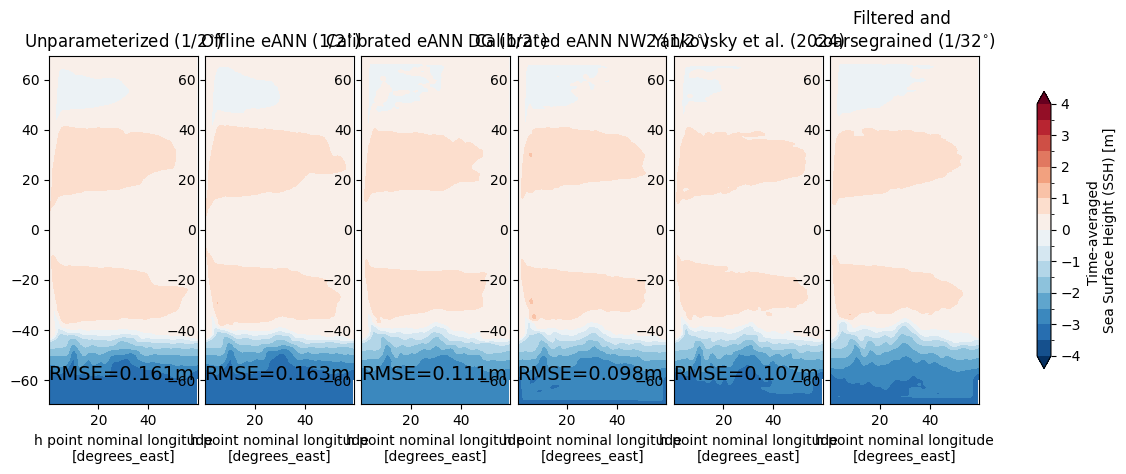

In [9]:
plot_ssh(mean_dict, ['unparameterized', 'eANN_offline', 'eANN_DG', 'eANN_NW2', 'Yankovsky24', 'truth'],
['Unparameterized ($1/2^{\circ}$)', 'Offline eANN ($1/2^{\circ}$)', 'Calibrated eANN DG ($1/2^{\circ}$)', 
'Calibrated eANN NW2 ($1/2^{\circ}$)', 'Yankovsky et al. (2024)', 'Filtered and \ncoarsegrained ($1/32^{\circ}$)'], zi=0)

# Zonally-averaged interfaces

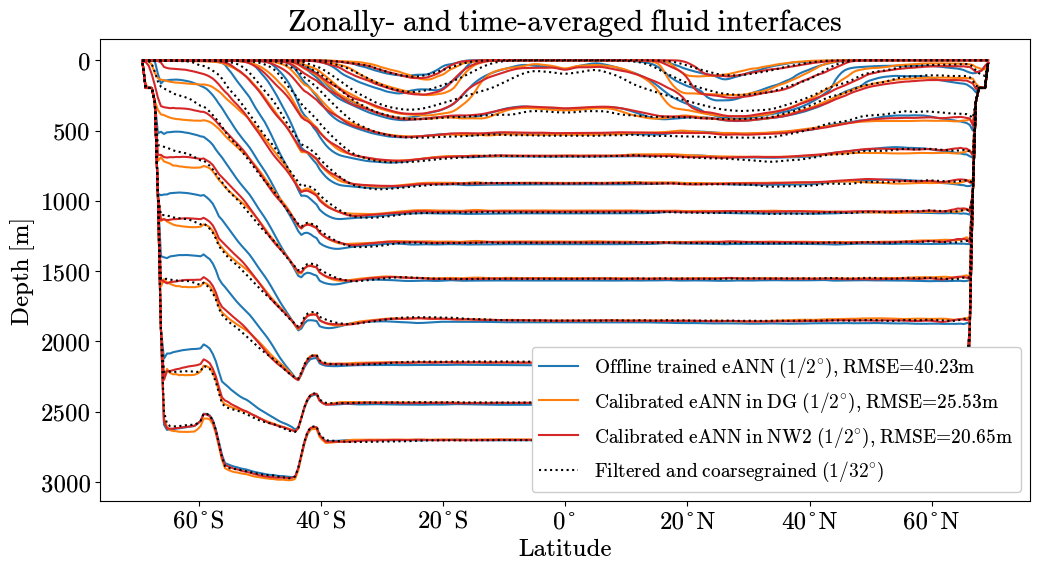

In [10]:
default_rcParams({'font.size': 18})
plt.figure(figsize=(12,6))

# interfaces = interface_dict['unparameterized']
# for zi in range(1,15):
#     interfaces.isel(zi=zi).plot(color='gray')
# rmse = np.sqrt(np.nanmean((interfaces - interface_dict['truth'])**2))
# plt.plot([], [], color='gray', label=f'Unparameterized (RMSE={rmse:.2f}m)')

interfaces = interface_dict['eANN_offline']
for zi in range(1,15):
    interfaces.isel(zi=zi).plot(color='tab:blue')
rmse = np.sqrt(np.nanmean((interfaces - interface_dict['truth'])**2))
plt.plot([], [], color='tab:blue', label='Offline trained eANN ($1/2^{\circ}$), ' + f'RMSE={rmse:.2f}m')

interfaces = interface_dict['eANN_DG']
for zi in range(1,15):
    interfaces.isel(zi=zi).plot(color='tab:orange')
rmse = np.sqrt(np.nanmean((interfaces - interface_dict['truth'])**2))
plt.plot([], [], color='tab:orange', label='Calibrated eANN in DG ($1/2^{\circ}$), ' + f'RMSE={rmse:.2f}m')

interfaces = interface_dict['eANN_NW2']
for zi in range(1,15):
    interfaces.isel(zi=zi).plot(color='tab:red')
rmse = np.sqrt(np.nanmean((interfaces - interface_dict['truth'])**2))
plt.plot([], [], color='tab:red', label='Calibrated eANN in NW2 ($1/2^{\circ}$), ' + f'RMSE={rmse:.2f}m')

# interfaces = interface_dict['Yankovsky24']
# for zi in range(1,15):
#     interfaces.isel(zi=zi).plot(color='tab:orange')
# rmse = np.sqrt(np.nanmean((interfaces - interface_dict['truth'])**2))
# plt.plot([], [], color='tab:orange', label=f'Yankovsky et al. (2024) (RMSE={rmse:.2f}m)')

interfaces = interface_dict['truth']
for zi in range(1,15):
    interfaces.isel(zi=zi).plot(color='k', ls=':')
plt.plot([], [], color='k', ls=':', label='Filtered and coarsegrained ($1/32^{\circ}$)')

plt.yticks(np.arange(-3000,500,500), np.arange(3000,-500,-500))
plt.xticks((-60, -40, -20, 0, 20, 40, 60), ('60°S', '40°S', '20°S', '0°', '20°N', '40°N', '60°N'))
plt.ylabel('Depth [m]')
plt.legend(loc='lower right', framealpha=1, fontsize=14)
plt.xlabel('Latitude')
plt.title('Zonally- and time-averaged fluid interfaces')
plt.savefig('paper_figures/Figure3-interfaces.pdf')

# SSH plot

In [11]:
from helpers.computational_tools import Lk_error
def plot_ssh_std(self, exps, labels=None, target=None, ncols=4, zi=0, vmax=3.0, cmap=cmocean.cm.amp, show_rmse=True):
    if labels is None:
        labels=exps
    nfig = len(exps)
    ncol = min(ncols,nfig)
    nrows = nfig / ncols
    if nrows > 1:
        nrows = int(np.ceil(nrows))
    else:
        nrows = 1

    if zi == 0:
        levels = np.arange(0,0.65,0.05)
        #levels=np.linspace(-2,1,10)
    else:
        levels = np.arange(0,65,5)

    
    plt.figure(figsize=(10,8))
    plt.subplots_adjust(hspace=0.05, wspace=0.05)

    for ifig, exp in enumerate(exps):
        plt.subplot(nrows,ncol,ifig+1)
        ssh_std = self[exp].isel(zi=zi)
        
        im = (ssh_std).plot.imshow(levels=levels, cmap=cmap, extend='both', add_colorbar=False)
        
        plt.xticks((10,30,50), ('10°E', '30°E', '50°E'))
        
        if ifig == 0:
            plt.yticks((-60, -40, -20, 0, 20, 40, 60), ('60°S', '40°S', '20°S', '0°', '20°N', '40°N', '60°N'))
            plt.ylabel('Latitude')
        else:
            plt.yticks((-60, -40, -20, 0, 20, 40, 60), ()*7)
            plt.ylabel('')
        plt.title(labels[ifig])
        plt.xlabel('')

        if exp != exps[-1]:
            RMSE = Lk_error(self[exp].isel(zi=zi),self[exps[-1]].isel(zi=zi))[0]
            corr = float(xr.corr(self[exp].isel(zi=zi),self[exps[-1]].isel(zi=zi)))
            #print(RMSE)
            if show_rmse:
                plt.text(5,5,'RMSE='+str(round(RMSE,3))+'m', fontsize=14, color='k')
                plt.text(5,-5,'corr='+str(round(corr,3)), fontsize=14, color='k')
        plt.gca().set_aspect(1)

    plt.colorbar(im, ax = plt.gcf().axes, label='Temporal STD of SSH [m]', shrink=0.8, pad=0.075, aspect=50, orientation='horizontal')

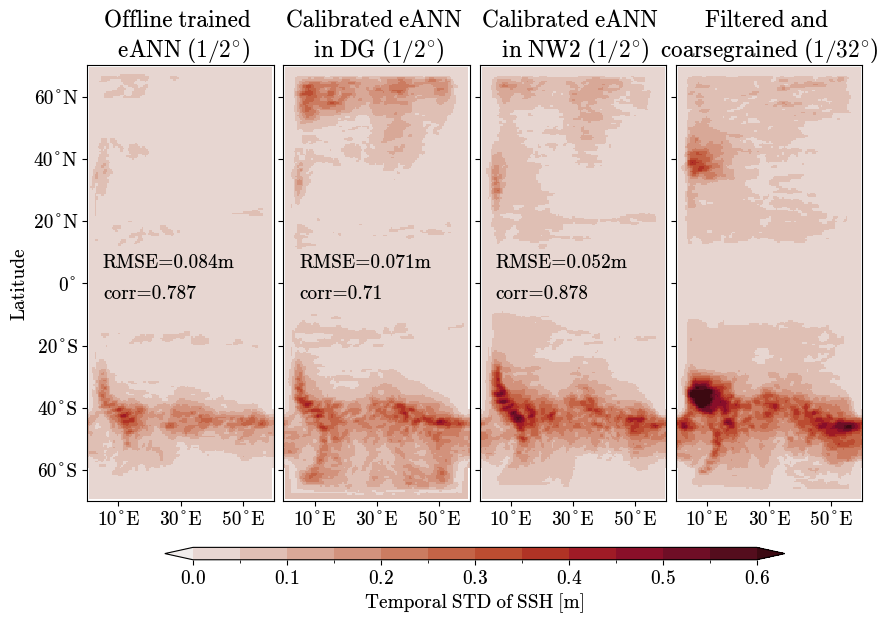

In [12]:
default_rcParams()
plot_ssh_std(std_dict, ['eANN_offline', 'eANN_DG', 'eANN_NW2', 'truth'],
['Offline trained \n eANN ($1/2^{\circ}$)', 'Calibrated eANN \n in DG ($1/2^{\circ}$)', 
'Calibrated eANN \n in NW2 ($1/2^{\circ}$)', 'Filtered and \ncoarsegrained ($1/32^{\circ}$)'], zi=0, ncols=5)
plt.savefig('paper_figures/Figure3-ssh-std.pdf')

# Robustness to the noise

In [69]:
data_ssh = []
data_std = []
e = ds['R2_FGR3_gprime_2-iteration-05-ens-member-100-100years'].prog.e.isel(zi=0)
for i in range(1,10):
    ssh = e.sel(Time=slice(365*10*i,365*10*(i+1)))
    print(ssh.Time.values)
    data_ssh.append(ssh.mean('Time').compute())
    data_std.append(ssh.std('Time').compute())
ssh = e.sel(Time=slice(365*10,None))
data_ssh.append(ssh.mean('Time').compute())
data_std.append(ssh.std('Time').compute())

[3660. 3690. 3720. 3750. 3780. 3810. 3840. 3870. 3900. 3930. 3960. 3990.
 4020. 4050. 4080. 4110. 4140. 4170. 4200. 4230. 4260. 4290. 4320. 4350.
 4380. 4410. 4440. 4470. 4500. 4530. 4560. 4590. 4620. 4650. 4680. 4710.
 4740. 4770. 4800. 4830. 4860. 4890. 4920. 4950. 4980. 5010. 5040. 5070.
 5100. 5130. 5160. 5190. 5220. 5250. 5280. 5310. 5340. 5370. 5400. 5430.
 5460. 5490. 5520. 5550. 5580. 5610. 5640. 5670. 5700. 5730. 5760. 5790.
 5820. 5850. 5880. 5910. 5940. 5970. 6000. 6030. 6060. 6090. 6120. 6150.
 6180. 6210. 6240. 6270. 6300. 6330. 6360. 6390. 6420. 6450. 6480. 6510.
 6540. 6570. 6600. 6630. 6660. 6690. 6720. 6750. 6780. 6810. 6840. 6870.
 6900. 6930. 6960. 6990. 7020. 7050. 7080. 7110. 7140. 7170. 7200. 7230.
 7260. 7290.]
[ 7320.  7350.  7380.  7410.  7440.  7470.  7500.  7530.  7560.  7590.
  7620.  7650.  7680.  7710.  7740.  7770.  7800.  7830.  7860.  7890.
  7920.  7950.  7980.  8010.  8040.  8070.  8100.  8130.  8160.  8190.
  8220.  8250.  8280.  8310.  8340.  8370. 

In [86]:
def plot_ssh(data, vmax=2, cmap=cmocean.cm.balance, add_colorbar=False, axes=True, show_rmse=False, figsize=(4,4),
            data_true=None, **kw):
    levels_field = np.arange(-vmax,vmax+0.5,0.5)
    
    #plt.figure(figsize=figsize)

    levels = np.arange(-vmax,vmax+0.5,0.5)
    data.plot.contourf(levels=levels, cmap=cmap, linewidths=1, extend='both', add_colorbar=add_colorbar, **kw)
    plt.title('')

    if axes:
        plt.xticks(np.arange(0,25,5), [f"{i}"+"$^{\circ}\mathrm{E}$" for i in np.arange(0,25,5)])
        plt.yticks(np.arange(30,55,5), [f"{i}"+"$^{\circ}\mathrm{N}$" for i in np.arange(30,55,5)])
        plt.xlabel('')
        plt.ylabel('')
    else:
        plt.xticks([])
        plt.yticks([])
        plt.xlabel('')
        plt.ylabel('')
    
    if show_rmse:
        rmse = float(np.sqrt(((data - data_true)**2).mean()))
        plt.text(1,31,f'RMSE$={rmse:.3f}$m', fontsize=16)

    plt.gca().set_aspect(1)

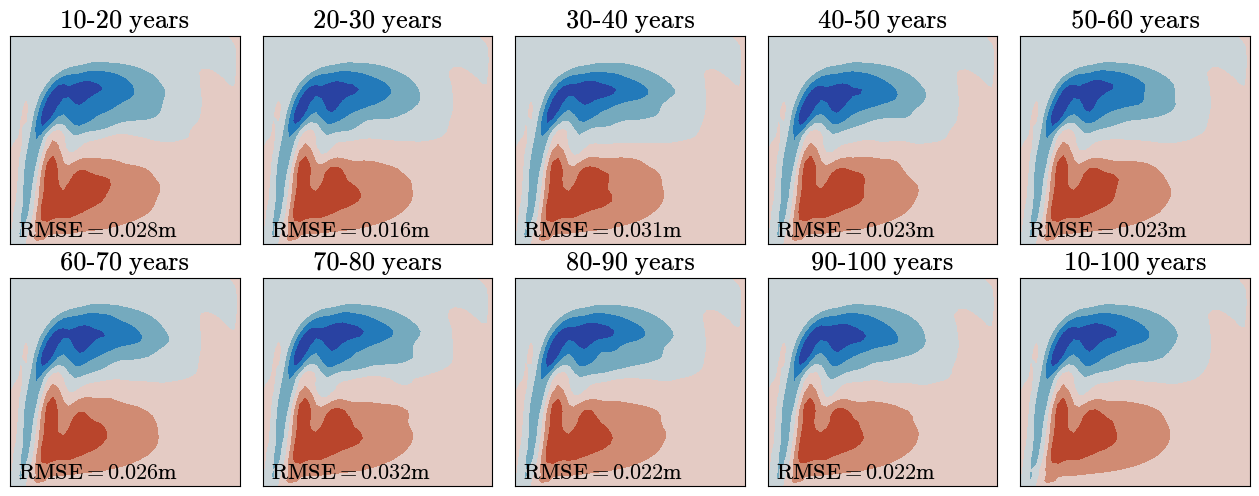

In [87]:
default_rcParams({'font.size': 16,'axes.formatter.limits': (-2,4), 'figure.subplot.wspace': 0.1, 'figure.subplot.hspace': 0.1})
plt.figure(figsize=(16,6))
for i in range(9):
    plt.subplot(2,5,i+1)
    plot_ssh(data_ssh[i], axes=False, show_rmse=True, data_true = data_ssh[-1])
    #plt.title("Calibrated eANN ($1/2^{\circ}$)"+"\n" +f"{(i+1)*10}-{(i+2)*10} years")
    plt.title(f"{(i+1)*10}-{(i+2)*10} years")
plt.subplot(2,5,10)
plot_ssh(data_ssh[-1], axes=False)
#plt.title("Calibrated eANN ($1/2^{\circ}$)"+"\n" +"10-100 years")
plt.title("10-100 years")
# plot_ssh(ds['R32_R2_FGR3'].ssh_mean, axes=False)
# plt.title('Filtered and \ncoarsegrained $1/32^{\circ}$\n 10-100years')
plt.savefig('paper_figures/ssh_mean_noise.pdf')

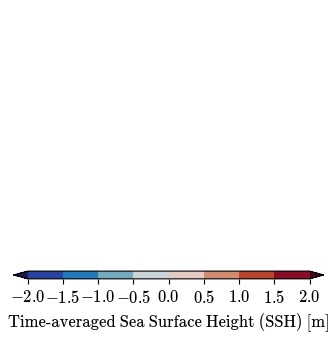

In [78]:
plot_ssh(data_ssh[0]*np.nan, axes=False, add_colorbar=True, figsize=(5,5),
cbar_kwargs={'label': 'Time-averaged Sea Surface Height (SSH) [m]', 'shrink':1.0, 'aspect':40, 'orientation':'horizontal'})
plt.title('')
plt.gca().set_frame_on(False)
plt.savefig('paper_figures/ssh_colorbar.pdf')

In [90]:
def plot_ssh_std(data, vmax=2, cmap=cmocean.cm.amp, add_colorbar=False, axes=True, show_rmse=False, figsize=(4,4),
                data_true=None, **kw):
    levels_field = np.arange(-vmax,vmax+0.5,0.5)
    
    #plt.figure(figsize=figsize)

    levels = np.arange(0,0.65,0.05)
    data.plot.contourf(levels=levels, cmap=cmap, linewidths=1, extend='both', add_colorbar=add_colorbar, **kw)
    plt.title('')

    if axes:
        plt.xticks(np.arange(0,25,5), [f"{i}"+"$^{\circ}\mathrm{E}$" for i in np.arange(0,25,5)])
        plt.yticks(np.arange(30,55,5), [f"{i}"+"$^{\circ}\mathrm{N}$" for i in np.arange(30,55,5)])
        plt.xlabel('')
        plt.ylabel('')
    else:
        plt.xticks([])
        plt.yticks([])
        plt.xlabel('')
        plt.ylabel('')
    
    if show_rmse:
        rmse = float(np.sqrt(((data - data_true)**2).mean()))
        plt.text(1,31,f'RMSE$={rmse:.3f}$m', fontsize=16)

    plt.gca().set_aspect(1)

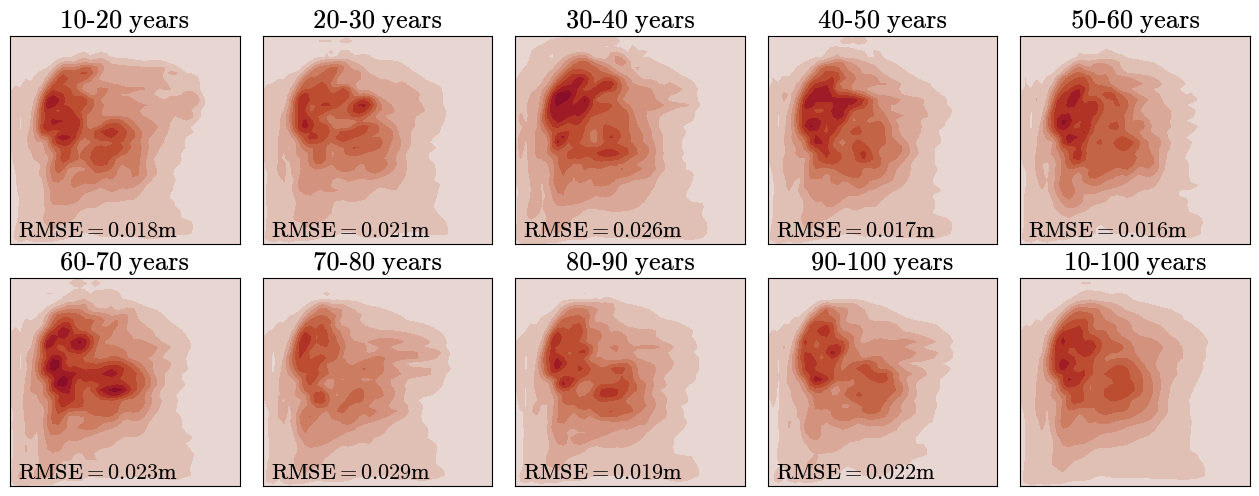

In [91]:
default_rcParams({'font.size': 16,'axes.formatter.limits': (-2,4), 'figure.subplot.wspace': 0.1, 'figure.subplot.hspace': 0.1})
plt.figure(figsize=(16,6))
for i in range(9):
    plt.subplot(2,5,i+1)
    plot_ssh_std(data_std[i], axes=False, data_true=data_std[-1], show_rmse=True)
    #plt.title("Calibrated eANN ($1/2^{\circ}$)"+"\n" +f"{(i+1)*10}-{(i+2)*10} years")
    plt.title(f"{(i+1)*10}-{(i+2)*10} years")
plt.subplot(2,5,10)
plot_ssh_std(data_std[-1], axes=False)
#plt.title("Calibrated eANN ($1/2^{\circ}$)"+"\n" +"10-100 years")
plt.title("10-100 years")
#plot_ssh_std(ds['R32_R2_FGR3'].ssh_std, axes=False)
#plt.title('Filtered and \ncoarsegrained $1/32^{\circ}$\n 10-100years')
plt.savefig('paper_figures/ssh_std_noise.pdf')

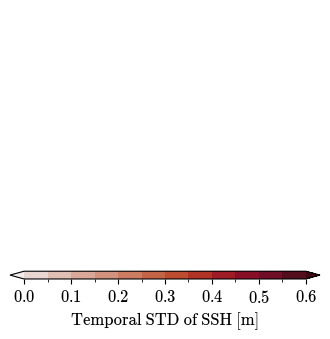

In [79]:
plot_ssh_std(data_ssh[0]*np.nan, axes=False, add_colorbar=True, figsize=(5,5),
cbar_kwargs={'label': 'Temporal STD of SSH [m]', 'shrink':1.0, 'aspect':40, 'orientation':'horizontal'})
plt.title('')
plt.gca().set_frame_on(False)
plt.savefig('paper_figures/ssh_std_colorbar.pdf')

In [92]:
params_default = xr.open_dataset('/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter/FGR3/equivariant/learning_rate/N8-forcing-fluxes/0.05/model/eANN.nc')

In [93]:
params_DG = xr.open_dataset('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_gprime_2/iteration-05/ens-member-100/INPUT/eANN.nc')

In [94]:
params_NW2 = xr.open_dataset('/scratch/pp2681/mom6/Neverworld2/calibration/1800days/gprime_n/iteration-03/ens-member-200/INPUT/eANN.nc')

In [97]:
np.abs(params_DG.weights2 - params_default.weights2).mean()

<xarray.DataArray 'weights2' ()> Size: 4B
array(0.20769884, dtype=float32)

In [98]:
np.abs(params_NW2.weights2 - params_default.weights2).mean()

<xarray.DataArray 'weights2' ()> Size: 4B
array(0.14692779, dtype=float32)

In [100]:
params_default.weights2.std() * 0.25

<xarray.DataArray 'weights2' ()> Size: 8B
array(0.18013276)

In [103]:
np.round(params_default.weights2.values,2)

array([ 0.68,  0.69,  1.15,  0.15,  0.6 , -0.6 ,  0.74,  0.01, -0.36,
        0.31, -0.04,  2.25], dtype=float32)

In [104]:
np.round(params_DG.weights2.values,2)

array([ 0.64,  0.66,  1.35,  0.23,  0.15, -0.5 ,  0.4 ,  0.29, -0.79,
        0.51, -0.19,  2.06], dtype=float32)

In [105]:
np.round(params_NW2.weights2.values,2)

array([ 0.85,  0.73,  1.29,  0.18,  0.35, -0.69,  0.21,  0.15, -0.44,
        0.48,  0.03,  2.18], dtype=float32)

In [106]:
print(np.round(params_default.biases2.values,2))
print(np.round(params_DG.biases2.values,2))
print(np.round(params_NW2.biases2.values,2))

[0.15]
[0.16]
[0.17]


In [107]:
params_default.biases2.values*0.25

array([0.03730748], dtype=float32)